In [2]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
# geopandas extends pandas to handle geospatial data and perform operations on geographic shapes.
import geopandas as gpd
# matplotlib.colors provides tools to define and manipulate colormaps for visualizations.
import matplotlib.colors as mcolors
# ListedColormap allows the creation of custom colormaps for visualizations.
from matplotlib.colors import ListedColormap
from pathlib import Path
from typing import List
from matplotlib.patches import Patch
from scipy.signal import find_peaks
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.optimize import nnls
#import matplotlib.colormaps as cm
import matplotlib.markers as mmarkers
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
# For PDPs
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import OneHotEncoder
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import math
from sklearn.model_selection import GridSearchCV
from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestClassifier


In [3]:


def collect_files(base_dir: str, dirs: List[str], subpath: str, pattern: str, exclude: str = None) -> List[str]:
    """
    Collects files matching a pattern from specified subdirectories.

    Parameters:
        base_dir (str): Base directory containing all subdirectories.
        dirs (List[str]): List of subdirectory names.
        subpath (str): Relative path inside each subdirectory where files are located.
        pattern (str): Glob pattern to match files.
        exclude (str, optional): String pattern to exclude from results.

    Returns:
        List[str]: Sorted list of matching file paths as strings.
    """
    all_files = []
    for d in dirs:
        search_path = Path(base_dir) / d / subpath / pattern
        files = sorted(search_path.parent.glob(search_path.name))
        if exclude:
            files = [f for f in files if exclude not in f.name]
        all_files.extend([str(f) for f in files])
    return all_files

# Base directory and subdirectories
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b748-oct-02", 
    "b749-oct-03", 
]

# Collect files
core_processed_files = collect_files(base_dir, dirs, "core_processed", "core_faam*r1*.nc", exclude="_1hz")
dry_neph_files = collect_files(base_dir, dirs, "mo-non-core", "metoffice*neph1*.nc")
flight_sum_files = collect_files(base_dir, dirs, ".", "flight-sum*.txt")
sp2_files = collect_files(base_dir, dirs, "non-core", "man-sp2*.na")
ams_files = collect_files(base_dir, dirs, "non-core", "man-ams*.na")
lidar_files = collect_files(base_dir, dirs, "non-core", "met*.nc")
core_processed_files_cloud = collect_files(base_dir, dirs, "core_processed", "core-cloud*r0*.nc")
co2_files = collect_files(base_dir,dirs,"non-core","faam-fgga*r1*.na")
#core-cloud-phy_faam_20120920_v500_r0_b737#

# Example: print or pass them into other analysis
# print(core_processed_files)


In [4]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_core = {extract_flight_number(f) for f in core_processed_files}
flights_ams = {extract_flight_number(f) for f in dry_neph_files}
flights_sp2 = {extract_flight_number(f) for f in sp2_files}
flights_neph = {extract_flight_number(f) for f in ams_files}
flights_cloud = {extract_flight_number(f) for f in core_processed_files_cloud}
flights_co2 = {extract_flight_number(f) for f in co2_files}

# Find flights that are in all three datasets
common_flights = flights_core & flights_ams & flights_sp2 & flights_neph & flights_cloud & flights_co2# Set intersection

# Filter the file lists to include only matching flights
filtered_core = [f for f in core_processed_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in ams_files if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in sp2_files if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in dry_neph_files if extract_flight_number(f) in common_flights]
filtered_cloud = [f for f in core_processed_files_cloud if extract_flight_number(f) in common_flights]
filtered_co2 = [f for f in co2_files if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered Core files: {len(filtered_core)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_neph)}")
print(f"Filtered Cloud files: {len(filtered_cloud)}")
print(f"Filtered Cloud files: {len(filtered_co2)}")

Common flights: ['b734', 'b737', 'b739', 'b742', 'b743', 'b744', 'b745', 'b746', 'b748', 'b749']
Filtered Core files: 10
Filtered AMS files: 10
Filtered SP2 files: 10
Filtered Neph files: 10
Filtered Cloud files: 10
Filtered Cloud files: 10


In [5]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_mid_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")

    key_options = ["neph_spm", "NEPH_SPM"]  # Possible variations of the key
    matching_key = next((key for key in key_options if key in dsf), None)
    
    if matching_key:
        time_seconds_t = dsf[matching_key].values
    else:
        raise KeyError("Variable 'neph_spm' not found in dataset.")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    #time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds_t])

    dsf = dsf.assign_coords(time=dsf['neph_spm'])
    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))
    #dsf["Times"] = (("time",), datetime_values)
    #dsf["datetime"] = (("time",), datetime_values)
    #dsf = dsf.set_coords('neph_spm')

    return dsf
def convert_time_to_datetime_co2(dsf, start_date_str):
    """
    Convert the 'Time_sec' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_sec'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_sec"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf

In [6]:
def dataset_sp2_ams_neph_co2(file_path_sp2,file_path_ams,file_path_co2,file_path_neph):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )
 
    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None

    ##############################################################################################################
    #CO2
    with open(file_path_co2, "rb") as f:
        lines_co2 = f.readlines()  # Read the first 100 bytes

    metadata_lines_co2 = lines_co2[:40]  # 39 lines are metadata
    data_lines_co2 = lines_co2[40:]  # Actual data starts after metadata
    # Define column names explicitly
    column_names = [
        "Time_sec",     # Seconds from 00:00 UTC of the flight date
        "CO2",          # ppm
        "CO2_FLAG",     # quality flag
        "CH4",          # ppm
        "CH4_FLAG"      # quality flag
    ]
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_co2], dtype=float)
    metadata_lines_co2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_co2]
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    
    
    # Convert to xarray Dataset with headers as variable names
    ds0_co2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(column_names)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_co2)}  # Store metadata as an attribute
    )
    # Extract the date (format: yyyymmdd)
    match_co2 = re.search(r'(\d{8})', file_path_co2)
    # Get the matched date or None if not found
    flight_date_co2 = match_co2.group(1) if match_co2 else None

    ##############################################################################################################

    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds0_sp2 = convert_time_to_datetime_sp2(ds0_sp2, flight_date_sp2)
    ds0_ams = convert_time_to_datetime_ams(ds0_ams, flight_date_ams)
    ds0_co2 = convert_time_to_datetime_co2(ds0_co2, flight_date_co2)
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds0_sp2,ds0_ams,ds0_co2,ds_neph

In [7]:
def dataset_sp2_ams_neph(file_path_sp2,file_path_ams,file_path_neph):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )
 
    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None


    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds0_sp2 = convert_time_to_datetime_sp2(ds0_sp2, flight_date_sp2)
    ds0_ams = convert_time_to_datetime_ams(ds0_ams, flight_date_ams)
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds0_sp2,ds0_ams,ds_neph

In [8]:
def file_ams_sp2_treatment_v3(aux_ds_sp2, aux_ds_ams):
    """
    Process AMS and SP2 datasets:
    - Filter invalid values
    - Exclude points where uncertainty > 0.5 * value
    - Resample to 1 min averages
    - Propagate uncertainties
    - Compute ammonium sulfate and nitrate mass concentrations
    """
    variables = ["SO4", "NH4", "ORG", "NO3", "Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]

    resampled_vars = {}
    resampled_uncs = {}

    for var, var_unc in zip(variables, variables_unc):
        # Mask invalid data
        valid_mask = (aux_ds_ams[var] != 9999999) & (aux_ds_ams[var_unc] != 9999999)

        # Additional restriction: only accept if uncertainty < 0.5 × value
        valid_mask &= aux_ds_ams[var_unc] < 0.5 * aux_ds_ams[var]

        data = aux_ds_ams[var].where(valid_mask)
        unc = aux_ds_ams[var_unc].where(valid_mask)

        # Resample (1 min mean)
        resampled_vars[var] = data.resample(datetime="1min").mean()

        # Count of valid points
        counts = data.resample(datetime="1min").count()

        # Propagate uncertainty: σ_mean = sqrt(sum(σ_i²)) / N
        sum_unc_sq = (unc ** 2).resample(datetime="1min").sum()
        resampled_uncs[var_unc] = np.sqrt(sum_unc_sq) / counts

    # Combine all processed variables
    resampled_ds_ams = xr.Dataset({**resampled_vars, **resampled_uncs})

    # --- Add derived variables ---
    # (NH4)2SO4 = 1.375 * SO4
    resampled_ds_ams["NH4_2SO4"] = 1.375 * resampled_ds_ams["SO4"]

    # NH4NO3 = 1.292 * NO3
    resampled_ds_ams["NH4NO3"] = 1.292 * resampled_ds_ams["NO3"]

    # Process BC_mass
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2["BC_mass"].where(valid_BC_mass_mask) * 1e-3  # Convert to µg/m³
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    return resampled_ds_ams, resampled_ds_sp2

In [9]:
results_sct_all = []

# Iterate over all matching flights
for sp2_file, ams_file, core_file, neph_file in zip(filtered_sp2, filtered_ams, filtered_core, filtered_neph):
    
    ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(sp2_file,ams_file,neph_file)
    ds_core = xr.open_dataset(core_file)

    # Resample to 1-minute mean
    ams_resampled, sp2_resampled = file_ams_sp2_treatment_v3(ds_sp2,ds_ams)
    resampled_neph = ds_neph.resample(datetime='1min').mean()

    resampled_core = ds_core.resample(Time='1min').mean()
    #resampled_core_filtered = resampled_core.where(resampled_core["CO_AERO_FLAG"] == 0, drop=True)
    resampled_core_filtered = (
    resampled_core
    .where(resampled_core["CO_AERO_FLAG"] == 0)
    .where(resampled_core["PSAP_LIN_FLAG"] == 0)
    .where(resampled_core["PSAP_LIN"] > 0, drop=True)
    )
    
    resampled_neph_time = resampled_neph["time"].values  # Reference timestamps
    ams_resampled_time = ams_resampled["time"].values
    sp2_resampled_time = sp2_resampled["time"].values
    resampled_core_time = resampled_core_filtered["data_point"].values

    
    # First find common times between neph and AMS
    common_times = np.intersect1d(resampled_neph_time, ams_resampled_time)
    
    # Then intersect with SP2
    common_times = np.intersect1d(common_times, sp2_resampled_time)

    # Then intersect with CORE
    common_times = np.intersect1d(common_times, resampled_core_time)
    
    #print(f"Number of common timestamps: {len(common_times)}")
    print(len(common_times))
    
    
    core_file_matched = resampled_core_filtered.sel(data_point=common_times)
    ams_resampled_matched = ams_resampled.sel(time=common_times)
    sp2_resampled_matched = sp2_resampled.sel(time=common_times)
    resampled_neph_matched = resampled_neph.sel(time=common_times)
    #GF, RH = growth_func_calc(core_file_matched)
    
    #Core file variables
    Height = core_file_matched['GPS_ALT'].values.squeeze()
    Lon = core_file_matched['LON_GPS'].values.squeeze()
    Lat = core_file_matched['LAT_GPS'].values.squeeze()
    CO_conc_matched = core_file_matched['CO_AERO'].values.squeeze()
    PSAP_matched = core_file_matched['PSAP_LIN'].values.squeeze()
    #Neph file variables
    TSC_blue = resampled_neph_matched["TSC_BLUU"].values.squeeze()
    TSC_green = resampled_neph_matched["TSC_GRNU"].values.squeeze()
    TSC_red = resampled_neph_matched["TSC_REDU"].values.squeeze()
    #Sp2 file variables
    BC = sp2_resampled_matched.values
    #AMS file variables
    ORG = ams_resampled_matched['ORG'].values
    
    #print('len BC:',len(BC))
    #print('len SIC:',len(SIC))
    #print('len Neph:',len(TSC_green))
    #print('len Dg:',len(Dg_aligned_matched))
    
    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', core_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"

    results_sct_all.append({
        'ORG': ORG,
        'ORG_corrected': ORG,
        'BC': BC,
        'TSC_blue':TSC_blue,
        'TSC_green':TSC_green,
        'TSC_red':TSC_red,
        'ABS_PSAP':PSAP_matched,
        'CO': CO_conc_matched,
        'ALT' : Height,
        'LON': Lon,
        'LAT': Lat,
        'flight': flight_number,
        'Time': core_file_matched['data_point'].values
    })


161
146
120
175
131
192
200
183
91
76


In [10]:
# Collect all datasets per flight
datasets = []

for entry in results_sct_all:
    try:

        # --- Create dataset ---
        ds = xr.Dataset(
            {
                # Scalar/time-varying variables
                "TSC_blue": (["time"], np.atleast_1d(entry["TSC_blue"])),
                "TSC_green": (["time"], np.atleast_1d(entry["TSC_green"])),
                "TSC_red": (["time"], np.atleast_1d(entry["TSC_red"])),
                "PSAP": (["time"], np.atleast_1d(entry["ABS_PSAP"])),
                "BC": (["time"], np.atleast_1d(entry["BC"])),
                "ORG": (["time"], np.atleast_1d(entry["ORG"])),
                "ALT": (["time"], np.atleast_1d(entry["ALT"])),
                "LON": (["time"], np.atleast_1d(entry["LON"])),
                "LAT": (["time"], np.atleast_1d(entry["LAT"])),
                "CO": (["time"], np.atleast_1d(entry["CO"])),
            },
            coords={
                "time": entry["Time"],
                "flight": entry["flight"],
            },
            attrs={
                "flight_number": entry["flight"],
            }
        )
        datasets.append(ds)

    except Exception as e:
        print(f"⚠️ Skipping flight {entry['flight']} due to error: {e}")

# --- Combine all flights into one dataset
ds_all_flights = xr.concat(datasets, dim="flight")

In [17]:
def extract_features(ds, flight_idx):
    """
    Extract feature matrix for one flight.
    """
    dsf = ds.isel(flight=flight_idx)

    X = pd.DataFrame({
        "CO": dsf["CO"].values,
        "BC": dsf["BC"].values,
        "ORG": dsf["ORG"].values,
        "ALT": dsf["ALT"].values,
    }, index=dsf["time"].values)

    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    return X


In [12]:
def initial_plume_labels(
    X,
    co_q=75,
    bc_q=75,
    org_q=75,
    bg_q=25
):
    """
    Create weak plume/background labels.

    Returns:
    label = 1 → plume
    label = 0 → background
    label = -1 → ignore
    """

    labels = pd.Series(-1, index=X.index)

    # Thresholds
    co_hi = np.nanpercentile(X["CO"], co_q)
    bc_hi = np.nanpercentile(X["BC"], bc_q)
    org_hi = np.nanpercentile(X["ORG"], org_q)

    co_lo = np.nanpercentile(X["CO"], bg_q)
    bc_lo = np.nanpercentile(X["BC"], bg_q)
    org_lo = np.nanpercentile(X["ORG"], bg_q)

    # Obvious plume
    plume_mask = (
        (X["CO"] > co_hi) &
        (X["BC"] > bc_hi) &
        (X["ORG"] > org_hi)
    )

    # Obvious background
    bg_mask = (
        (X["CO"] < co_lo) &
        (X["BC"] < bc_lo) &
        (X["ORG"] < org_lo)
    )

    labels[plume_mask] = 1
    labels[bg_mask] = 0

    return labels


In [13]:
def train_rf_plume_classifier(X, labels):
    """
    Train Random Forest using only confident labels.
    """

    mask_train = labels >= 0

    X_train = X.loc[mask_train]
    y_train = labels.loc[mask_train]

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    )

    rf.fit(X_train, y_train)

    return rf


In [14]:
def predict_plume_probability(rf, X):
    """
    Predict plume probability for all points.
    """
    prob = rf.predict_proba(X)[:, 1]
    return pd.Series(prob, index=X.index)


In [18]:
flight_idx = 1  # choose manually

X = extract_features(ds_all_flights, flight_idx)
labels_weak = initial_plume_labels(X)

rf = train_rf_plume_classifier(X, labels_weak)
plume_prob = predict_plume_probability(rf, X)


In [16]:
x_clean = X.replace([np.inf, -np.inf], np.nan).dropna()

In [ ]:
x_clean

In [19]:
def plot_plume_rf_diagnostic(X, labels, plume_prob, tracer="ORG"):
    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # Tracer with weak labels
    ax[0].plot(X.index, X[tracer], color="k", lw=0.8)
    ax[0].scatter(X.index[labels == 1], X[tracer][labels == 1],
                  color="red", s=15, label="Weak plume")
    ax[0].scatter(X.index[labels == 0], X[tracer][labels == 0],
                  color="blue", s=15, label="Weak background")
    ax[0].set_ylabel(tracer)
    ax[0].legend()

    # RF plume probability
    ax[1].plot(X.index, plume_prob, color="darkorange")
    ax[1].set_ylabel("Plume probability")
    ax[1].set_ylim(0, 1)
    ax[1].set_xlabel("Time")
    #ax[1].set_xlim(pd.to_datetime(2012-09-18T9:00:00), pd.to_datetime(2012-09-18T20:00:00))

    plt.tight_layout()
    plt.show()


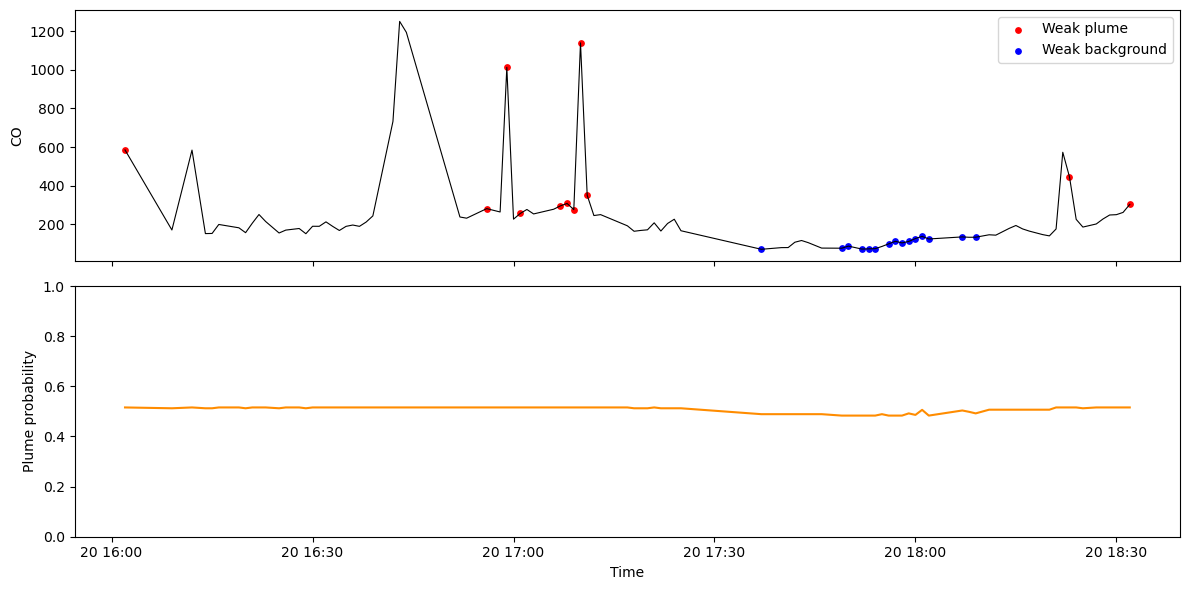

In [21]:
plot_plume_rf_diagnostic(X, labels_weak, plume_prob, tracer="CO")


In [22]:
def add_plume_features(X, window=5):
    """
    Add rolling baseline and enhancement features.
    window = number of minutes
    """
    Xf = X.copy()

    for tracer in ["CO", "BC", "ORG"]:
        rolling_bg = Xf[tracer].rolling(
            window=window,
            center=True,
            min_periods=1
        ).median()

        Xf[f"{tracer}_bg"] = rolling_bg
        Xf[f"{tracer}_delta"] = Xf[tracer] - rolling_bg
        Xf[f"{tracer}_ratio"] = Xf[tracer] / rolling_bg

    return Xf


In [23]:
def add_temporal_gradients(X):
    Xg = X.copy()

    for tracer in ["CO", "BC", "ORG"]:
        Xg[f"{tracer}_d1"] = Xg[tracer].diff()

    return Xg


In [24]:
X_raw = extract_features(ds_all_flights, flight_idx)

X_feat = add_plume_features(X_raw, window=5)
X_feat = add_temporal_gradients(X_feat)

# Drop rows with NaNs introduced by rolling/diff
X_feat = X_feat.dropna()


In [25]:
labels_feat = labels_weak.loc[X_feat.index]

rf = train_rf_plume_classifier(X_feat, labels_feat)
plume_prob = predict_plume_probability(rf, X_feat)


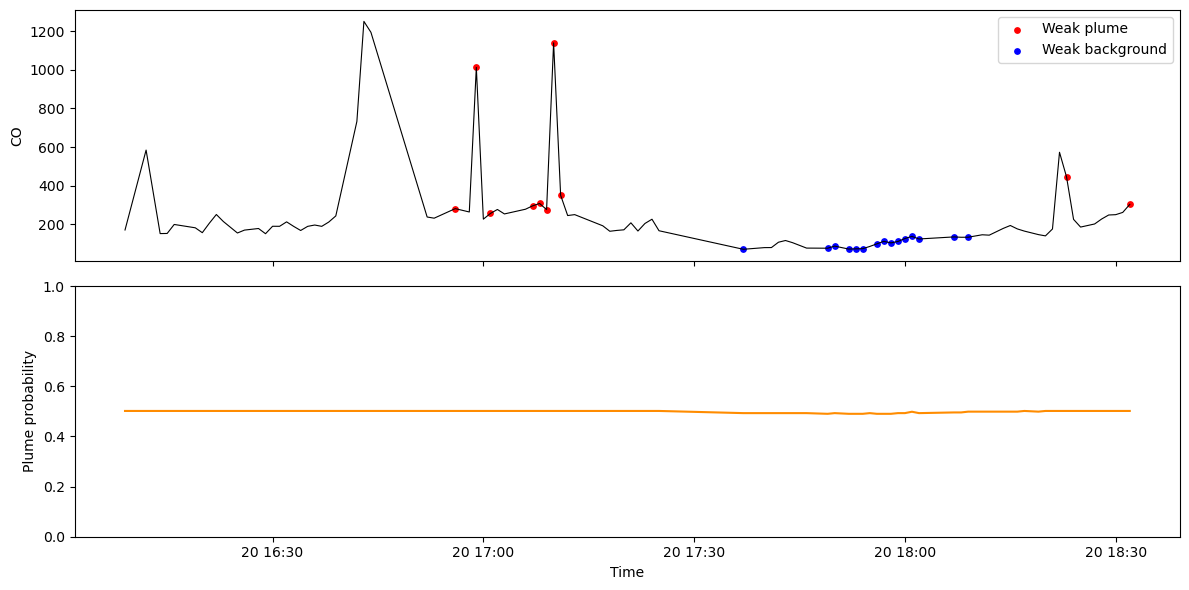

In [26]:
plot_plume_rf_diagnostic(
    X_feat,
    labels_feat,
    plume_prob,
    tracer="CO"
)
